# Reproducibility Notebook - Deployment-Aligned Evaluation with Temporal and Geographic Holdouts
**Author:** Herislei Pimentel  
**Manuscript:** Research Paper v2.2  
**Date:** 28 September 2026

This notebook is an archival, deterministic research copy of the computational workflow that generated the results reported in the manuscript. It was originally developed for a PhD technical assessment and is retained here because the manuscript reuses those verified empirical outputs. The analytical code is preserved rather than reconstructed from prose.

### Core design principles
1. **No target leakage in forecasting.** `casual` and `registered` sum to `count`; they are excluded from predictive features.
2. **Conservative temporal holdout.** For each month, days 21 through month-end are evaluated using only eligible day 1-20 observations available before that window; evaluation labels are not recycled into later fits.
3. **Exogenous-weather assumption is explicit.** Weather-enhanced forecasting uses observed weather fields as a proxy for covariates that would need to be supplied ex ante in deployment.
4. **City-level geographic holdout.** Austin, Chicago, and Kitsap are used for training; Tyrol-W for validation; Vienna is an author-defined held-out labeled city.
5. **Deterministic segmentation execution.** Python, NumPy, PyTorch, CUDA, DataLoader, and model-initialization seeds are fixed at 42, with deterministic CuDNN settings and deterministic algorithms requested where available.
6. **Bounded inference.** Results support only the protocols actually executed; random-split counterfactuals, rotating held-out cities, and multi-seed uncertainty are not claimed in this notebook.


## 0. Environment and configuration
The workflow is designed for a standard Python environment; a CUDA GPU is strongly recommended for the segmentation section. The notebook downloads the public UCI Bike Sharing dataset and the official Inria aerial-image files at runtime. Exact package versions from the original 2026 Colab runtime were not archived, so environment-level reproducibility is partial even though seeds and analytical settings are explicit.


In [1]:
# Install only packages that are not guaranteed in a clean Colab runtime.
import sys, subprocess, importlib.util

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name or import_name])

for imp, pipn in [
    ('statsmodels','statsmodels'),
    ('segmentation_models_pytorch','segmentation-models-pytorch'),
    ('tifffile','tifffile'),
    ('rasterio','rasterio'),
    ('requests','requests'),
]:
    ensure_package(imp, pipn)

print('Environment ready.')

Environment ready.


In [2]:
from pathlib import Path
import os, re, io, math, json, random, zipfile, shutil, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path.cwd()
OUT = ROOT / 'unlv_assessment_outputs'
OUT.mkdir(exist_ok=True)

# Part 2 settings. The defaults are deliberately bounded so the complete notebook
# can run on a Colab T4 while still sampling every labeled tile in each city split.
PATCH_SIZE = 512
GRID_SIDE = 4             # 4 x 4 = 16 spatially distributed patches per tile
BATCH_SIZE = 8
MAX_EPOCHS = 8
PATIENCE = 3

print('Output directory:', OUT.resolve())

Output directory: /content/unlv_assessment_outputs


# Part 1 - Capital Bikeshare Demand Analysis & Forecasting

## 1. Data loading and schema reconciliation
The assessment links to the UCI Bike Sharing Dataset. The official `hour.csv` stores temperature, humidity, and wind speed in normalized form, whereas the assessment describes human-readable units. I convert the UCI fields into the assessment schema while retaining the original values for traceability.

In [3]:
import requests

UCI_ZIP = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
GITHUB_FALLBACK = 'https://raw.githubusercontent.com/udacity/deep-learning/master/first-neural-network/Bike-Sharing-Dataset/hour.csv'

def load_bike_data():
    cache = OUT / 'hour.csv'
    if cache.exists():
        raw = pd.read_csv(cache)
    else:
        try:
            r = requests.get(UCI_ZIP, timeout=60)
            r.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
                raw = pd.read_csv(zf.open('hour.csv'))
            raw.to_csv(cache, index=False)
        except Exception as e:
            print('UCI ZIP unavailable, using public GitHub mirror:', type(e).__name__)
            raw = pd.read_csv(GITHUB_FALLBACK)
            raw.to_csv(cache, index=False)
    return raw

raw = load_bike_data()

bike = pd.DataFrame({
    'datetime': pd.to_datetime(raw['dteday']) + pd.to_timedelta(raw['hr'], unit='h'),
    'season': raw['season'].astype(int),
    'holiday': raw['holiday'].astype(int),
    'workingday': raw['workingday'].astype(int),
    'weather': raw['weathersit'].astype(int),
    # UCI documentation: normalized by 41, 50, 100 and 67 respectively.
    'temp': raw['temp'] * 41.0,
    'atemp': raw['atemp'] * 50.0,
    'humidity': raw['hum'] * 100.0,
    'windspeed': raw['windspeed'] * 67.0,
    'casual': raw['casual'].astype(int),
    'registered': raw['registered'].astype(int),
    'count': raw['cnt'].astype(int),
})

bike['year'] = bike['datetime'].dt.year
bike['month'] = bike['datetime'].dt.month
bike['day'] = bike['datetime'].dt.day
bike['hour'] = bike['datetime'].dt.hour
bike['weekday'] = bike['datetime'].dt.dayofweek  # Monday=0
bike['period'] = bike['datetime'].dt.to_period('M')

assert (bike['casual'] + bike['registered'] == bike['count']).all(), 'count identity failed'
assert bike['datetime'].is_monotonic_increasing, 'dataset should be chronological'
assert bike.isna().sum().sum() == 0, 'unexpected missing values'

print(f'Rows: {len(bike):,}')
print('Date range:', bike.datetime.min(), 'to', bike.datetime.max())
print('Missing values:', int(bike.isna().sum().sum()))
display(bike.head())

Rows: 17,379
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Missing values: 0


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday,period
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81.0,0.0,3,13,16,2011,1,1,0,5,2011-01
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80.0,0.0,8,32,40,2011,1,1,1,5,2011-01
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80.0,0.0,5,27,32,2011,1,1,2,5,2011-01
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75.0,0.0,3,10,13,2011,1,1,3,5,2011-01
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75.0,0.0,0,1,1,2011,1,1,4,5,2011-01


### Leakage note
Because `count = casual + registered` exactly, including either user-count component in a demand model would leak target information. I therefore use `casual` and `registered` only to understand user behavior. All predictive models use calendar and exogenous weather variables only.

## 2. Task 1 - Descriptive statistics and exploratory analysis
I focus on three questions that are operationally useful: (1) when demand peaks, (2) how registered and casual users differ, and (3) how adverse weather changes demand.

In [4]:
summary = bike[['temp','atemp','humidity','windspeed','casual','registered','count']].describe().T
summary['variance'] = bike[['temp','atemp','humidity','windspeed','casual','registered','count']].var()
summary.to_csv(OUT/'part1_descriptive_statistics.csv')
display(summary.round(2))

count_mean = bike['count'].mean()
count_var = bike['count'].var()
print(f'Count mean = {count_mean:.2f}; variance = {count_var:.2f}; variance/mean = {count_var/count_mean:.1f}')
print(f'Overall casual share = {bike.casual.sum()/bike["count"].sum():.1%}')
print('Maximum hourly count:', bike['count'].max(), 'at', bike.loc[bike['count'].idxmax(),'datetime'])

,count,mean,std,min,25%,50%,75%,max,variance
temp,17379.0,20.38,7.89,0.82,13.94,20.50,27.06,41.0,62.33
atemp,17379.0,23.79,8.59,0.00,16.66,24.24,31.06,50.0,73.83
humidity,17379.0,62.72,19.29,0.00,48.00,63.00,78.00,100.0,372.22
windspeed,17379.0,12.74,8.20,0.00,7.00,13.00,17.00,57.0,67.19
casual,17379.0,35.68,49.31,0.00,4.00,17.00,48.00,367.0,2430.99
registered,17379.0,153.79,151.36,0.00,34.00,115.00,220.00,886.0,22909.03
count,17379.0,189.46,181.39,1.00,40.00,142.00,281.00,977.0,32901.46


Count mean = 189.46; variance = 32901.46; variance/mean = 173.7
Overall casual share = 18.8%
Maximum hourly count: 977 at 2012-09-12 18:00:00


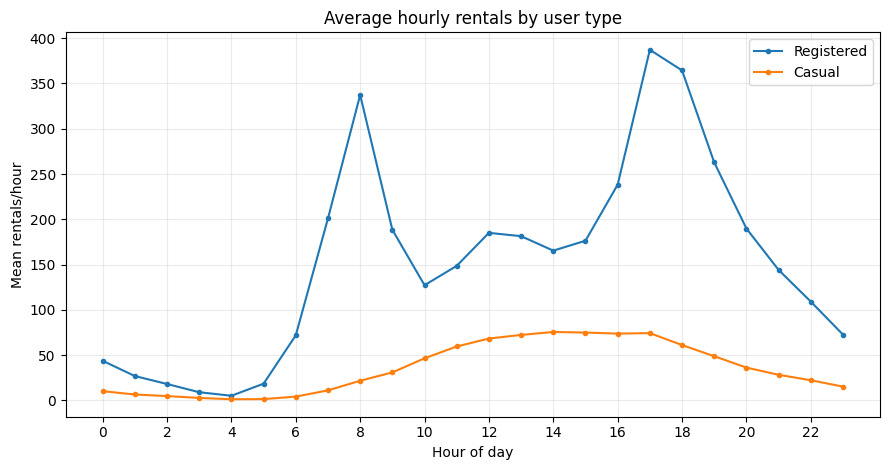

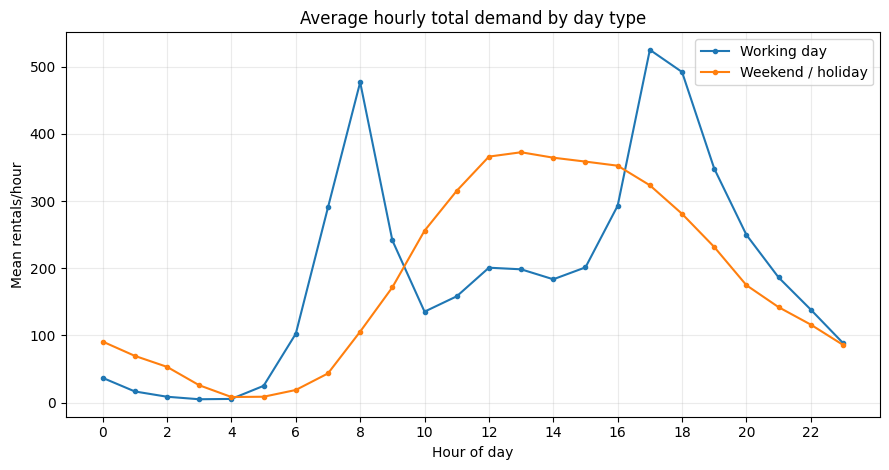

In [5]:
# Hourly behavioral dynamics: registered vs casual and working vs non-working days.
hour_users = bike.groupby('hour')[['casual','registered']].mean()
hour_work = bike.groupby(['hour','workingday'])['count'].mean().unstack()

fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(hour_users.index, hour_users['registered'], marker='o', ms=3, label='Registered')
ax.plot(hour_users.index, hour_users['casual'], marker='o', ms=3, label='Casual')
ax.set(title='Average hourly rentals by user type', xlabel='Hour of day', ylabel='Mean rentals/hour')
ax.set_xticks(range(0,24,2)); ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
fig.savefig(OUT/'part1_user_type_hourly.png', dpi=180); plt.show()

fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(hour_work.index, hour_work.get(1), marker='o', ms=3, label='Working day')
ax.plot(hour_work.index, hour_work.get(0), marker='o', ms=3, label='Weekend / holiday')
ax.set(title='Average hourly total demand by day type', xlabel='Hour of day', ylabel='Mean rentals/hour')
ax.set_xticks(range(0,24,2)); ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
fig.savefig(OUT/'part1_workingday_hourly.png', dpi=180); plt.show()

,count,mean,median,std
weather,,,,
Clear / partly cloudy,11413,204.87,159.0,189.49
Mist / cloudy,4544,175.17,133.0,165.43
Light rain/snow,1419,111.58,63.0,133.78
Heavy rain/snow,3,74.33,36.0,77.93


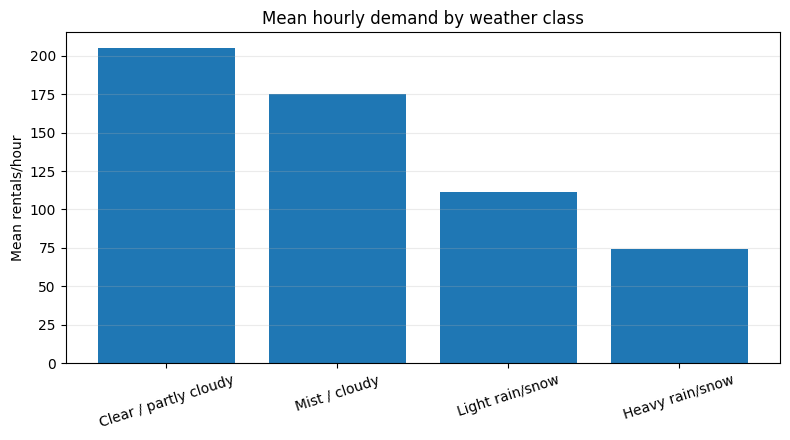

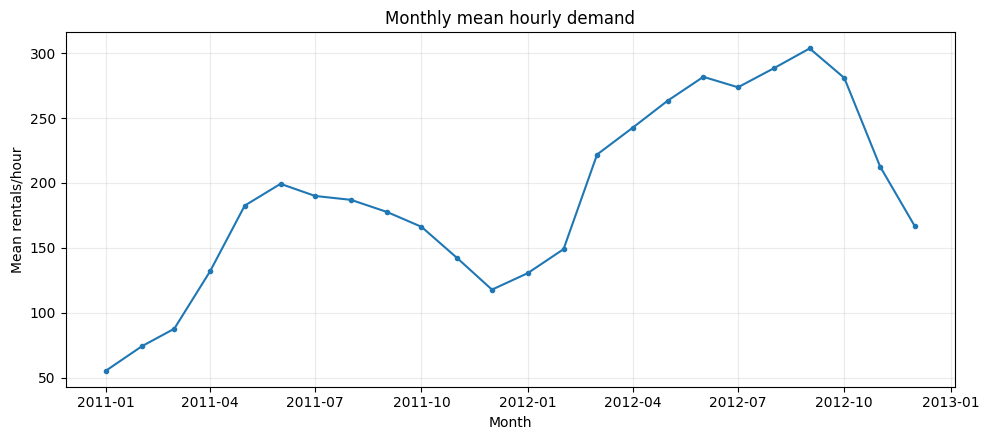

In [6]:
weather_labels = {1:'Clear / partly cloudy',2:'Mist / cloudy',3:'Light rain/snow',4:'Heavy rain/snow'}
weather_stats = (bike.groupby('weather')['count']
                 .agg(['count','mean','median','std'])
                 .rename(index=weather_labels))
weather_stats.to_csv(OUT/'part1_weather_stats.csv')
display(weather_stats.round(2))

fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(weather_stats.index, weather_stats['mean'])
ax.set(title='Mean hourly demand by weather class', ylabel='Mean rentals/hour')
ax.tick_params(axis='x', rotation=18); ax.grid(axis='y', alpha=.25); fig.tight_layout()
fig.savefig(OUT/'part1_weather_demand.png', dpi=180); plt.show()

monthly = bike.set_index('datetime')['count'].resample('MS').mean()
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(monthly.index, monthly.values, marker='o', ms=3)
ax.set(title='Monthly mean hourly demand', ylabel='Mean rentals/hour', xlabel='Month')
ax.grid(alpha=.25); fig.tight_layout()
fig.savefig(OUT/'part1_monthly_demand.png', dpi=180); plt.show()

In [7]:
# A few compact EDA quantities that are useful in the written discussion.
workday_profile = bike.groupby('workingday')[['casual','registered','count']].mean().round(2)
weather_drop = 1 - weather_stats.loc['Light rain/snow','mean'] / weather_stats.loc['Clear / partly cloudy','mean']
peak_work = int(hour_work[1].idxmax())
peak_nonwork = int(hour_work[0].idxmax())

eda_facts = {
    'peak_workingday_hour': peak_work,
    'peak_nonworkingday_hour': peak_nonwork,
    'light_precipitation_drop_vs_clear': float(weather_drop),
    'casual_share': float(bike.casual.sum()/bike['count'].sum()),
    'count_variance_to_mean': float(count_var/count_mean),
    'temp_atemp_correlation': float(bike[['temp','atemp']].corr().iloc[0,1])
}
print(json.dumps(eda_facts, indent=2))
display(workday_profile)

{
  "peak_workingday_hour": 17,
  "peak_nonworkingday_hour": 13,
  "light_precipitation_drop_vs_clear": 0.4553635098206078,
  "casual_share": 0.18830168382645257,
  "count_variance_to_mean": 173.65631224052666,
  "temp_atemp_correlation": 0.9876721390396507
}


,casual,registered,count
workingday,,,
0,57.44,123.96,181.41
1,25.56,167.65,193.21


## 3. Task 2 - Statistical and regression analysis
### Model choice
Hourly rentals are non-negative integer counts and are strongly overdispersed. I first fit a Poisson GLM as a diagnostic, then fit a Negative Binomial GLM. The regression is intended for inference and effect interpretation, not as the final forecasting model.

### Variable selection logic
- Hour and month are categorical because their effects are strongly nonlinear.
- `workingday x hour` captures the different commute shape on working days.
- Weather is categorical rather than ordinal in the regression.
- Temperature, humidity, and wind speed enter as continuous exposures.
- I retain `temp` and drop `atemp` because they are highly correlated; including both would inflate coefficient uncertainty without adding much physical information.
- `casual` and `registered` are excluded because they are components of the target.

In [8]:
# Collinearity diagnostic for continuous weather variables.
cont = bike[['temp','atemp','humidity','windspeed']].copy()
Xv = sm.add_constant(StandardScaler().fit_transform(cont), has_constant='add')
vif = pd.DataFrame({
    'variable':['const']+cont.columns.tolist(),
    'VIF':[variance_inflation_factor(Xv, i) for i in range(Xv.shape[1])]
})
print('Correlation temp vs atemp:', bike[['temp','atemp']].corr().iloc[0,1])
display(vif.round(2))

Correlation temp vs atemp: 0.9876721390396507


,variable,VIF
0,const,1.00
1,temp,43.55
2,atemp,43.65
3,humidity,1.10
4,windspeed,1.16


In [9]:
reg = bike.copy()
reg['temp5'] = reg['temp']/5.0
reg['humidity10'] = reg['humidity']/10.0
reg['wind10'] = reg['windspeed']/10.0

formula = ('count ~ C(hour) + workingday + C(hour):workingday + C(month) + '
           'C(weather) + temp5 + humidity10 + wind10 + holiday + C(year)')

pois = smf.glm(formula=formula, data=reg, family=sm.families.Poisson()).fit(cov_type='HC3')
pearson_dispersion = float(np.sum(pois.resid_pearson**2) / pois.df_resid)
print(f'Poisson Pearson dispersion = {pearson_dispersion:.2f} (values well above 1 indicate overdispersion)')

# Method-of-moments alpha gives a transparent starting dispersion level for NB2.
mu, var = reg['count'].mean(), reg['count'].var()
alpha = max((var-mu)/(mu**2), 1e-6)
nb = smf.glm(formula=formula, data=reg,
             family=sm.families.NegativeBinomial(alpha=alpha)).fit(cov_type='HC3')

selected_terms = ['temp5','humidity10','wind10','C(weather)[T.2]','C(weather)[T.3]','C(weather)[T.4]','C(year)[T.2012]']
rows=[]
for term in selected_terms:
    if term in nb.params.index:
        b=nb.params[term]; se=nb.bse[term]
        rows.append({
            'term':term, 'coef':b, 'robust_se':se, 'p_value':nb.pvalues[term],
            'IRR':np.exp(b), 'IRR_low':np.exp(b-1.96*se), 'IRR_high':np.exp(b+1.96*se)
        })
reg_table = pd.DataFrame(rows)
reg_table.to_csv(OUT/'part1_negative_binomial_selected_terms.csv', index=False)
display(reg_table.round(4))

Poisson Pearson dispersion = 14.37 (values well above 1 indicate overdispersion)


,term,coef,robust_se,p_value,IRR,IRR_low,IRR_high
0,temp5,0.1689,0.0046,0.0,1.1840,1.1735,1.1947
1,humidity10,-0.0174,0.0023,0.0,0.9827,0.9783,0.9871
2,wind10,-0.0429,0.0038,0.0,0.9580,0.9508,0.9652
3,C(weather)[T.2],-0.0624,0.0074,0.0,0.9395,0.9259,0.9533
4,C(weather)[T.3],-0.5072,0.0165,0.0,0.6022,0.5830,0.6219
5,C(weather)[T.4],-0.5478,0.1047,0.0,0.5782,0.4709,0.7100
6,C(year)[T.2012],0.4734,0.0059,0.0,1.6055,1.5871,1.6241


**Interpretation caution:** because hour interacts with working-day status, the raw main coefficient for `workingday` is not a global working-day effect; it is the contrast at the reference hour. The hourly profile plot is more interpretable for that behavior. Likewise, statistical significance is not the same as practical importance in a dataset with more than 17,000 observations.

## 4. Task 3 - Demand forecasting and predictive modeling
### Evaluation design
For month *m*, the evaluation window is day 21 through month-end. The model sees only day 1-20 observations from month *m* and from previous months. Labels from earlier evaluation windows are deliberately not recycled into training; this keeps the professor's requested split intact and prevents test information from leaking into later monthly models.

I compare:
1. **Historical hourly baseline** - mean demand by hour and working-day status.
2. **Calendar-only gradient boosting** - usable without a weather forecast.
3. **Calendar + weather gradient boosting** - treats weather fields as exogenous forecasts available before the rental hour.
4. **Random forest on log-demand** - a nonlinear tree ensemble as an independent model family.

Metrics are **MAE** (operational units: bikes/hour), **RMSE** (penalizes peak misses), and **RMSLE** (relative error across the skewed demand range). MAPE is avoided because near-zero overnight counts make percentage error unstable.

In [10]:
def add_features(df):
    x = df.copy()
    # Cyclical encodings preserve the 23->0 and Dec->Jan adjacency.
    x['hour_sin'] = np.sin(2*np.pi*x['hour']/24)
    x['hour_cos'] = np.cos(2*np.pi*x['hour']/24)
    x['month_sin'] = np.sin(2*np.pi*(x['month']-1)/12)
    x['month_cos'] = np.cos(2*np.pi*(x['month']-1)/12)
    x['dow_sin'] = np.sin(2*np.pi*x['weekday']/7)
    x['dow_cos'] = np.cos(2*np.pi*x['weekday']/7)
    x['year_index'] = x['year'] - 2011
    x['month_index'] = (x['year']-2011)*12 + (x['month']-1)
    x['commute_peak'] = (x['workingday'].eq(1) & x['hour'].isin([7,8,9,16,17,18,19])).astype(int)
    x['nonwork_daytime'] = (x['workingday'].eq(0) & x['hour'].between(10,18)).astype(int)
    for w in [2,3,4]:
        x[f'weather_{w}'] = (x['weather']==w).astype(int)
    return x

calendar_features = [
    'holiday','workingday','hour_sin','hour_cos','month_sin','month_cos',
    'dow_sin','dow_cos','year_index','month_index','commute_peak','nonwork_daytime'
]
weather_features = calendar_features + ['temp','humidity','windspeed','weather_2','weather_3','weather_4']

feat = add_features(bike)

def rmsle(y, p):
    p=np.clip(np.asarray(p),0,None)
    return float(np.sqrt(mean_squared_log_error(y,p)))

def score(y,p):
    p=np.clip(np.asarray(p),0,None)
    return {
        'MAE':float(mean_absolute_error(y,p)),
        'RMSE':float(np.sqrt(mean_squared_error(y,p))),
        'RMSLE':rmsle(y,p)
    }

def baseline_predict(train, test):
    means = train.groupby(['hour','workingday'])['count'].mean()
    hour_means = train.groupby('hour')['count'].mean()
    overall = train['count'].mean()
    vals=[]
    for _,r in test.iterrows():
        vals.append(means.get((r.hour,r.workingday), hour_means.get(r.hour, overall)))
    return np.asarray(vals)

periods = sorted(feat['period'].unique())
monthly_rows=[]
all_predictions=[]

for period in periods:
    current = feat[feat['period']==period]
    test = current[current['day']>=21].copy()
    if test.empty:
        continue
    test_start = test['datetime'].min()
    # Strict: only professor-defined training observations, and only before this test window.
    train = feat[(feat['day']<=20) & (feat['datetime'] < test_start)].copy()
    if len(train) < 100:
        continue

    models = {
        'Baseline': None,
        'HGB-calendar': HistGradientBoostingRegressor(loss='poisson', learning_rate=.06,
                         max_iter=220, max_leaf_nodes=31, min_samples_leaf=20,
                         l2_regularization=1.0, random_state=SEED),
        'HGB-weather': HistGradientBoostingRegressor(loss='poisson', learning_rate=.06,
                         max_iter=260, max_leaf_nodes=31, min_samples_leaf=20,
                         l2_regularization=1.0, random_state=SEED),
        'RF-weather-log': RandomForestRegressor(n_estimators=220, min_samples_leaf=2,
                         max_features=.85, n_jobs=-1, random_state=SEED)
    }
    preds={}
    preds['Baseline'] = baseline_predict(train,test)

    models['HGB-calendar'].fit(train[calendar_features], train['count'])
    preds['HGB-calendar'] = models['HGB-calendar'].predict(test[calendar_features])

    models['HGB-weather'].fit(train[weather_features], train['count'])
    preds['HGB-weather'] = models['HGB-weather'].predict(test[weather_features])

    models['RF-weather-log'].fit(train[weather_features], np.log1p(train['count']))
    preds['RF-weather-log'] = np.expm1(models['RF-weather-log'].predict(test[weather_features]))

    for name,p in preds.items():
        sc=score(test['count'],p)
        monthly_rows.append({'period':str(period),'model':name,'n_train':len(train),'n_test':len(test),**sc})
        tmp=test[['datetime','count']].copy(); tmp['period']=str(period); tmp['model']=name; tmp['prediction']=np.clip(p,0,None)
        all_predictions.append(tmp)

monthly_metrics = pd.DataFrame(monthly_rows)
predictions = pd.concat(all_predictions, ignore_index=True)

# Overall metrics computed on concatenated predictions, not the unweighted mean of monthly metrics.
overall=[]
for model,g in predictions.groupby('model'):
    overall.append({'model':model, **score(g['count'],g['prediction']), 'n':len(g)})
overall_metrics = pd.DataFrame(overall).sort_values('RMSLE')
overall_metrics.to_csv(OUT/'part1_forecast_overall_metrics.csv', index=False)
monthly_metrics.to_csv(OUT/'part1_forecast_monthly_metrics.csv', index=False)
predictions.to_csv(OUT/'part1_forecast_predictions.csv', index=False)

display(overall_metrics.round(3))

,model,MAE,RMSE,RMSLE,n
2,HGB-weather,36.592,61.882,0.461,5919
3,RF-weather-log,39.140,65.496,0.465,5919
1,HGB-calendar,47.529,82.660,0.543,5919
0,Baseline,77.269,115.381,0.627,5919


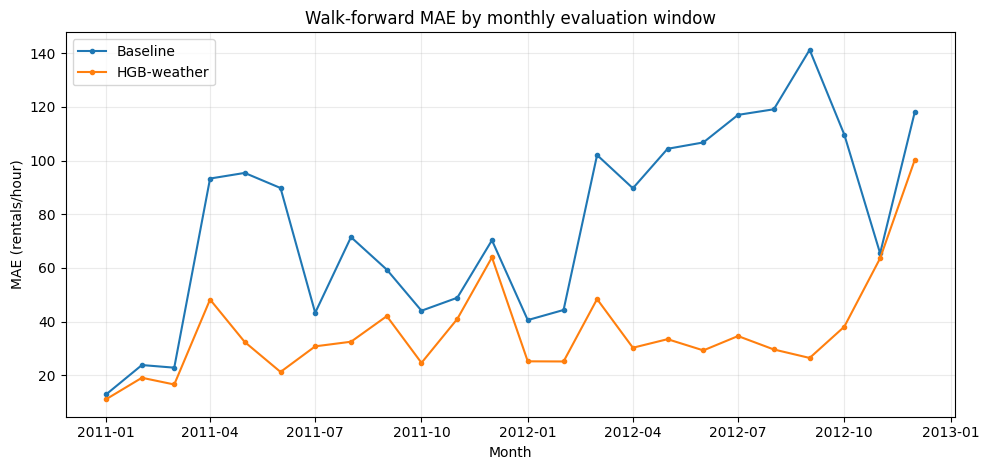

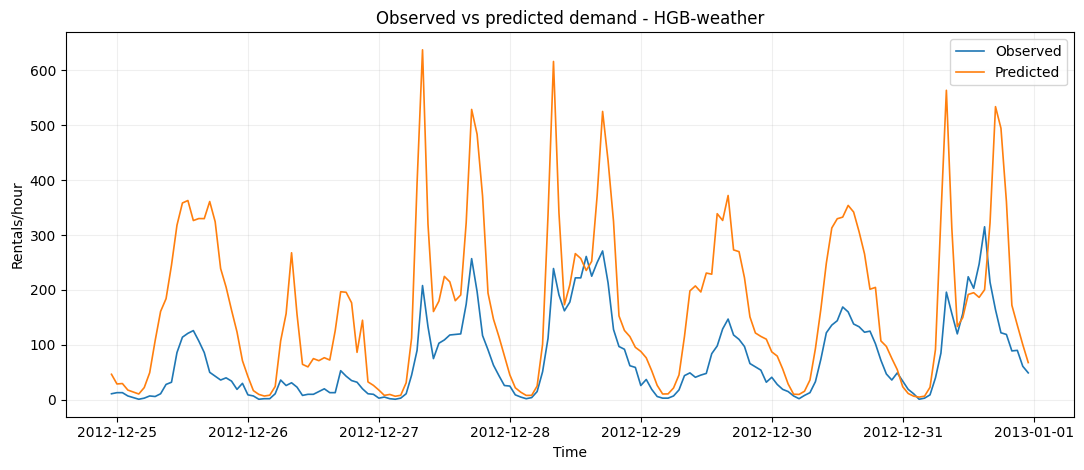

In [11]:
best_model_name = overall_metrics.iloc[0]['model']
plot_df = monthly_metrics[monthly_metrics['model'].isin(['Baseline',best_model_name])]
fig, ax = plt.subplots(figsize=(10,4.8))
for name,g in plot_df.groupby('model'):
    ax.plot(pd.to_datetime(g['period']), g['MAE'], marker='o', ms=3, label=name)
ax.set(title='Walk-forward MAE by monthly evaluation window', xlabel='Month', ylabel='MAE (rentals/hour)')
ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
fig.savefig(OUT/'part1_monthly_forecast_mae.png', dpi=180); plt.show()

best_pred = predictions[predictions.model==best_model_name].copy()
# Representative one-week section from late in the horizon for visual inspection.
end = best_pred.datetime.max(); start=end-pd.Timedelta(days=7)
vis=best_pred[best_pred.datetime>=start]
fig, ax = plt.subplots(figsize=(11,4.8))
ax.plot(vis.datetime, vis['count'], lw=1.2, label='Observed')
ax.plot(vis.datetime, vis['prediction'], lw=1.2, label='Predicted')
ax.set(title=f'Observed vs predicted demand - {best_model_name}', ylabel='Rentals/hour', xlabel='Time')
ax.legend(); ax.grid(alpha=.2); fig.tight_layout()
fig.savefig(OUT/'part1_forecast_example.png', dpi=180); plt.show()

In [12]:
# Permutation importance on the final 2012 test window, using a model fitted strictly on eligible training rows.
last_period = periods[-1]
last_test = feat[(feat.period==last_period) & (feat.day>=21)].copy()
last_start = last_test.datetime.min()
last_train = feat[(feat.day<=20) & (feat.datetime < last_start)].copy()
importance_model = HistGradientBoostingRegressor(loss='poisson', learning_rate=.06, max_iter=260,
                    max_leaf_nodes=31, min_samples_leaf=20, l2_regularization=1.0, random_state=SEED)
importance_model.fit(last_train[weather_features], last_train['count'])
pi = permutation_importance(importance_model, last_test[weather_features], last_test['count'],
                            scoring='neg_mean_absolute_error', n_repeats=5, random_state=SEED)
importance = pd.DataFrame({'feature':weather_features,'importance':pi.importances_mean}).sort_values('importance',ascending=False)
importance.to_csv(OUT/'part1_feature_importance.csv',index=False)
display(importance.head(12).round(3))

,feature,importance
16,weather_3,5.276
2,hour_sin,5.103
13,humidity,1.512
17,weather_4,0.000
8,year_index,0.000
4,month_sin,0.000
5,month_cos,0.000
9,month_index,0.000
15,weather_2,-0.026
14,windspeed,-0.091


### Patch-sampling note for the manuscript
For each 5000 x 5000 labeled tile, `grid_coords()` uses `np.linspace(0, 5000-512, 4)`, yielding start coordinates **0, 1496, 2992, and 4488 pixels** on each axis. The 4 x 4 grid therefore contains 16 non-overlapping 512 x 512 patches and samples 4,194,304 pixels, approximately **16.8% of each tile area**. This is spatially distributed sampling, not full-tile coverage.


# Part 2 - Building Footprint Segmentation

## 5. Spatial split strategy
The labeled Inria training set contains five cities. I split at **city level before patching**:
- **Train:** Austin, Chicago, Kitsap
- **Validation:** Tyrol-W
- **Test:** Vienna

This is deliberately stricter than randomly assigning image patches. Adjacent or overlapping patches from the same geographic tile can be nearly identical; random patch splitting would therefore overstate generalization. A city holdout makes the evaluation answer the more useful question: *can the model identify buildings in a geography it never saw during training?*

Within each 5000 x 5000 tile I sample a deterministic 4 x 4 grid of non-overlapping 512 x 512 patches. Every tile contributes spatially distributed samples, but no patch crosses split boundaries.

In [14]:
# Data acquisition from the official Inria public files.
# The dataset is cached after extraction so repeated runs do not re-download it.
import requests, subprocess

INRIA_BASE = ROOT / 'inria_data'

def find_inria_root(base):
    """Return the directory containing train/images and train/gt, if fully extracted."""
    if not base.exists():
        return None
    for images_dir in base.rglob('images'):
        if images_dir.parent.name.lower() != 'train':
            continue
        gt_dir = images_dir.parent / 'gt'
        n_img = len(list(images_dir.glob('*.tif')))
        n_gt = len(list(gt_dir.glob('*.tif'))) if gt_dir.exists() else 0
        if n_img >= 100 and n_gt >= 100:
            return images_dir.parent.parent
    return None

def extract_official_inria(base):
    """Download the multipart official archive and extract its internal ZIP safely."""
    base.mkdir(exist_ok=True)

    parts = [
        f'https://files.inria.fr/aerialimagelabeling/aerialimagelabeling.7z.{i:03d}'
        for i in range(1, 6)
    ]

    # Download only missing multipart files.
    for url in parts:
        target = base / url.split('/')[-1]
        if not target.exists():
            print('Downloading', target.name)
            with requests.get(url, stream=True, timeout=120) as r:
                r.raise_for_status()
                with open(target, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)

    if shutil.which('7z') is None:
        subprocess.check_call(['apt-get', 'update', '-qq'])
        subprocess.check_call(['apt-get', 'install', '-y', '-qq', 'p7zip-full'])

    first_part = base / 'aerialimagelabeling.7z.001'
    subprocess.check_call(['7z', 'x', str(first_part), f'-o{base}', '-y'])

    # Some distributions of the official archive contain a ZIP inside the multipart 7z archive.
    root = find_inria_root(base)
    if root is not None:
        return root

    zip_candidates = list(base.rglob('NEW2-AerialImageDataset.zip'))
    if not zip_candidates:
        zip_candidates = list(base.rglob('*AerialImageDataset*.zip'))

    if not zip_candidates:
        raise FileNotFoundError(
            'The multipart archive was extracted, but the internal Inria ZIP was not found.'
        )

    zip_path = zip_candidates[0]
    if not zipfile.is_zipfile(zip_path):
        raise RuntimeError(f'Internal archive is not a valid ZIP: {zip_path}')

    # Once the internal ZIP is validated, the multipart files can be deleted to free disk space
    # before expanding the full image dataset.
    for part in base.glob('aerialimagelabeling.7z.*'):
        part.unlink(missing_ok=True)

    print('Extracting', zip_path.name)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(base)

    root = find_inria_root(base)
    if root is None:
        raise FileNotFoundError(
            'Inria extraction completed, but train/images and train/gt could not be located.'
        )

    # The large intermediate ZIP is no longer needed after successful validation.
    zip_path.unlink(missing_ok=True)
    return root

inria_root = find_inria_root(INRIA_BASE)

if inria_root is None:
    try:
        inria_root = extract_official_inria(INRIA_BASE)
    except Exception as e:
        print('Official Inria download/extraction failed:', repr(e))
        print('Trying a public Kaggle mirror...')
        ensure_package('kagglehub', 'kagglehub')
        import kagglehub
        mirror = Path(
            kagglehub.dataset_download(
                'sagar100rathod/inria-aerial-image-labeling-dataset'
            )
        )
        inria_root = find_inria_root(mirror)

if inria_root is None:
    raise FileNotFoundError(
        'Could not locate a complete Inria train/images and train/gt dataset.'
    )

IMG_DIR = inria_root / 'train' / 'images'
GT_DIR = inria_root / 'train' / 'gt'

n_images = len(list(IMG_DIR.glob('*.tif')))
n_masks = len(list(GT_DIR.glob('*.tif')))

print('Inria root:', inria_root)
print('Labeled images:', n_images)
print('Ground-truth masks:', n_masks)

assert n_images == n_masks and n_images >= 100, 'Incomplete Inria extraction'


Official Inria download/extraction failed: CalledProcessError(2, ['7z', 'x', '/content/inria_data/aerialimagelabeling.7z.001', '-o/content/inria_data', '-y'])
Trying a public Kaggle mirror...


100%|██████████| 20.5G/20.5G [18:01<00:00, 20.4MB/s]

Extracting files...


Inria root: /root/.cache/kagglehub/datasets/sagar100rathod/inria-aerial-image-labeling-dataset/versions/1/AerialImageDataset
Labeled images: 180
Ground-truth masks: 180


In [16]:
from PIL import Image, ImageEnhance
import tifffile

def city_name(path):
    stem=Path(path).stem.lower()
    if stem.startswith('tyrol-w'): return 'tyrol-w'
    return re.match(r'[a-z]+', stem).group(0)

images=sorted(IMG_DIR.glob('*.tif'))
pairs=[]
for ip in images:
    mp=GT_DIR/ip.name
    if mp.exists(): pairs.append((ip,mp,city_name(ip)))

split_map={'austin':'train','chicago':'train','kitsap':'train','tyrol-w':'val','vienna':'test'}
pair_df=pd.DataFrame(pairs,columns=['image','mask','city'])
pair_df['split']=pair_df.city.map(split_map)
print(pair_df.groupby(['split','city']).size())
assert pair_df['split'].notna().all(), 'unexpected city naming'

split  city   
test   vienna     36
train  austin     36
       chicago    36
       kitsap     36
val    tyrol-w    36
dtype: int64


In [17]:
# Deterministic, non-overlapping 4x4 grid from each tile.
def grid_coords(tile_size=5000, patch=PATCH_SIZE, n=GRID_SIDE):
    xs=np.linspace(0,tile_size-patch,n).round().astype(int)
    return [(int(x),int(y)) for y in xs for x in xs]

coords=grid_coords()
patch_rows=[]
for _,r in pair_df.iterrows():
    for x,y in coords:
        patch_rows.append({
    'image': r['image'],
    'mask': r['mask'],
    'city': r['city'],
    'split': r['split'],
    'x': x,
    'y': y
})
patch_df=pd.DataFrame(patch_rows)
print(patch_df.groupby(['split','city']).size())
print('Total patches:',len(patch_df))

split  city   
test   vienna     576
train  austin     576
       chicago    576
       kitsap     576
val    tyrol-w    576
dtype: int64
Total patches: 2880


## 6. Model, loss, and training logic
I use a **U-Net with a ResNet-34 encoder initialized from ImageNet**. U-Net is appropriate because building extraction requires both semantic context and accurate localization; the skip connections preserve fine spatial information while the encoder supplies multiscale features.

The loss combines:
- **weighted binary cross-entropy** for class imbalance,
- **soft Dice loss** for overlap quality,
- a small **boundary loss** based on morphological edge maps to discourage blurred building edges.

The final objective is `0.45*BCE + 0.45*Dice + 0.10*Boundary`.

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision.transforms import functional as TF
import rasterio
from rasterio.windows import Window
import segmentation_models_pytorch as smp

# Reproducibility for Part 2
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

print("Part 2 deterministic seed:", SEED)

DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',DEVICE)

IMAGENET_MEAN=torch.tensor([0.485,0.456,0.406]).view(3,1,1)
IMAGENET_STD=torch.tensor([0.229,0.224,0.225]).view(3,1,1)

class InriaPatchDataset(Dataset):
    def __init__(self, frame, augment=False):
        self.frame=frame.reset_index(drop=True)
        self.augment=augment
    def __len__(self): return len(self.frame)
    def __getitem__(self, idx):
        r=self.frame.iloc[idx]
        # Windowed GeoTIFF I/O avoids loading a full 5000x5000 tile for every patch.
        y,x=int(r['y']),int(r['x'])
        win=Window(x,y,PATCH_SIZE,PATCH_SIZE)
        with rasterio.open(r['image']) as src:
            img=src.read([1,2,3],window=win).transpose(1,2,0)
        with rasterio.open(r['mask']) as src:
            mask=src.read(1,window=win)
        if self.augment:
            k=random.randint(0,3)
            img=np.rot90(img,k).copy(); mask=np.rot90(mask,k).copy()
            if random.random()<.5: img=np.fliplr(img).copy(); mask=np.fliplr(mask).copy()
            if random.random()<.5: img=np.flipud(img).copy(); mask=np.flipud(mask).copy()
            # mild photometric jitter on RGB only
            pil=Image.fromarray(img.astype(np.uint8))
            pil=ImageEnhance.Brightness(pil).enhance(random.uniform(.9,1.1))
            pil=ImageEnhance.Contrast(pil).enhance(random.uniform(.9,1.1))
            img=np.asarray(pil)
        img=torch.from_numpy(img.copy()).permute(2,0,1).float()/255.0
        img=(img-IMAGENET_MEAN)/IMAGENET_STD
        mask=torch.from_numpy((mask>127).astype(np.float32)).unsqueeze(0)
        return img,mask,{'city':r['city'],'image':Path(r['image']).name,'x':x,'y':y}

train_ds=InriaPatchDataset(patch_df[patch_df.split=='train'],augment=True)
val_ds=InriaPatchDataset(patch_df[patch_df.split=='val'],augment=False)
test_ds=InriaPatchDataset(patch_df[patch_df.split=='test'],augment=False)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=g
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(len(train_ds), len(val_ds), len(test_ds))

Device: cuda
1728 576 576


In [23]:
# Estimate foreground imbalance from a reproducible subset of training masks.
def estimate_pos_weight(ds, n=200):
    idx=np.linspace(0,len(ds)-1,min(n,len(ds))).astype(int)
    pos=neg=0
    old=ds.augment; ds.augment=False
    for i in idx:
        _,m,_=ds[i]; p=float(m.sum()); pos+=p; neg+=m.numel()-p
    ds.augment=old
    return float(np.clip(neg/max(pos,1),1.0,8.0))

pos_weight_value=estimate_pos_weight(train_ds)
print('Estimated positive-class weight:',pos_weight_value)
pos_weight=torch.tensor([pos_weight_value],device=DEVICE)

# Reset PyTorch RNG immediately before model initialization
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model=smp.Unet(encoder_name='resnet34',encoder_weights='imagenet',in_channels=3,classes=1,activation=None).to(DEVICE)

def dice_loss(logits,target,eps=1e-6):
    p=torch.sigmoid(logits)
    inter=(p*target).sum(dim=(1,2,3))
    denom=p.sum(dim=(1,2,3))+target.sum(dim=(1,2,3))
    return (1-(2*inter+eps)/(denom+eps)).mean()

def soft_boundary(x):
    maxp=F.max_pool2d(x,3,1,1)
    minp=-F.max_pool2d(-x,3,1,1)
    return (maxp-minp).clamp(0,1)

def combined_loss(logits,target):
    bce=F.binary_cross_entropy_with_logits(logits,target,pos_weight=pos_weight)
    dl=dice_loss(logits,target)
    pb=soft_boundary(torch.sigmoid(logits)); tb=soft_boundary(target)
    bl=F.l1_loss(pb,tb)
    return .45*bce+.45*dl+.10*bl, {'bce':bce.item(),'dice_loss':dl.item(),'boundary':bl.item()}

Estimated positive-class weight: 5.956942664881855


In [24]:
def batch_metrics(logits,target,threshold=.5):
    p=(torch.sigmoid(logits)>=threshold)
    t=(target>=.5)
    dims=(1,2,3)
    tp=(p&t).sum(dims).float(); fp=(p&~t).sum(dims).float(); fn=(~p&t).sum(dims).float()
    iou=((tp+1e-6)/(tp+fp+fn+1e-6))
    dice=((2*tp+1e-6)/(2*tp+fp+fn+1e-6))
    prec=((tp+1e-6)/(tp+fp+1e-6)); rec=((tp+1e-6)/(tp+fn+1e-6))
    # Boundary F1 with a 2-pixel tolerance (5x5 dilation).
    pe=soft_boundary(p.float())>.1; te=soft_boundary(t.float())>.1
    te_d=F.max_pool2d(te.float(),5,1,2)>0; pe_d=F.max_pool2d(pe.float(),5,1,2)>0
    match_p=(pe&te_d).sum(dims).float(); match_t=(te&pe_d).sum(dims).float()
    bp=(match_p+1e-6)/(pe.sum(dims).float()+1e-6); br=(match_t+1e-6)/(te.sum(dims).float()+1e-6)
    bf1=(2*bp*br+1e-6)/(bp+br+1e-6)
    return {'IoU':iou,'Dice':dice,'Precision':prec,'Recall':rec,'BoundaryF1':bf1}

@torch.no_grad()
def evaluate(loader):
    model.eval(); rows=[]; losses=[]
    for xb,yb,meta in loader:
        xb=xb.to(DEVICE,non_blocking=True); yb=yb.to(DEVICE,non_blocking=True)
        logits=model(xb); loss,_=combined_loss(logits,yb); losses.append(loss.item())
        m=batch_metrics(logits,yb)
        for i in range(len(xb)):
            rows.append({k:float(v[i].cpu()) for k,v in m.items()})
    df=pd.DataFrame(rows)
    return float(np.mean(losses)), df

In [25]:
optimizer=torch.optim.AdamW(model.parameters(),lr=3e-4,weight_decay=1e-4)
scaler=torch.amp.GradScaler('cuda',enabled=torch.cuda.is_available())

best_iou=-1; best_state=None; wait=0; history=[]
for epoch in range(1,MAX_EPOCHS+1):
    model.train(); train_losses=[]
    for xb,yb,_ in train_loader:
        xb=xb.to(DEVICE,non_blocking=True); yb=yb.to(DEVICE,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda',enabled=torch.cuda.is_available()):
            logits=model(xb); loss,_=combined_loss(logits,yb)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_losses.append(loss.item())
    val_loss,val_metrics=evaluate(val_loader)
    row={'epoch':epoch,'train_loss':np.mean(train_losses),'val_loss':val_loss,**val_metrics.mean().to_dict()}
    history.append(row); print(row)
    if row['IoU']>best_iou+1e-4:
        best_iou=row['IoU']; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; wait=0
    else:
        wait+=1
        if wait>=PATIENCE:
            print('Early stopping.'); break

model.load_state_dict(best_state)
torch.save(best_state,OUT/'part2_unet_resnet34_best.pt')
history_df=pd.DataFrame(history); history_df.to_csv(OUT/'part2_training_history.csv',index=False)

{'epoch': 1, 'train_loss': np.float64(0.5673455725665446), 'val_loss': 0.4929281390375561, 'IoU': 0.24853908643082065, 'Dice': 0.33058995847342115, 'Precision': 0.25368680625032586, 'Recall': 0.9433959424977993, 'BoundaryF1': 0.15504443305351462}
{'epoch': 2, 'train_loss': np.float64(0.46651967628686514), 'val_loss': 0.4776075780391693, 'IoU': 0.3274099937584967, 'Dice': 0.4125439850215129, 'Precision': 0.34448765653547286, 'Recall': 0.9279861084536734, 'BoundaryF1': 0.2533711065528927}
{'epoch': 3, 'train_loss': np.float64(0.4200678118677051), 'val_loss': 0.46507202254401314, 'IoU': 0.314587929741993, 'Dice': 0.39788727289383696, 'Precision': 0.3284597735978223, 'Recall': 0.934097464627859, 'BoundaryF1': 0.24637977571643116}
{'epoch': 4, 'train_loss': np.float64(0.4220461428717331), 'val_loss': 0.5516572967171669, 'IoU': 0.4374824867445126, 'Dice': 0.5142802105408274, 'Precision': 0.49616916125727506, 'Recall': 0.8571822952112461, 'BoundaryF1': 0.43210933969537496}
{'epoch': 5, 'train

,mean,std
IoU,0.5876,0.1955
Dice,0.7156,0.2045
Precision,0.6345,0.1979
Recall,0.8859,0.1588
BoundaryF1,0.2967,0.1889


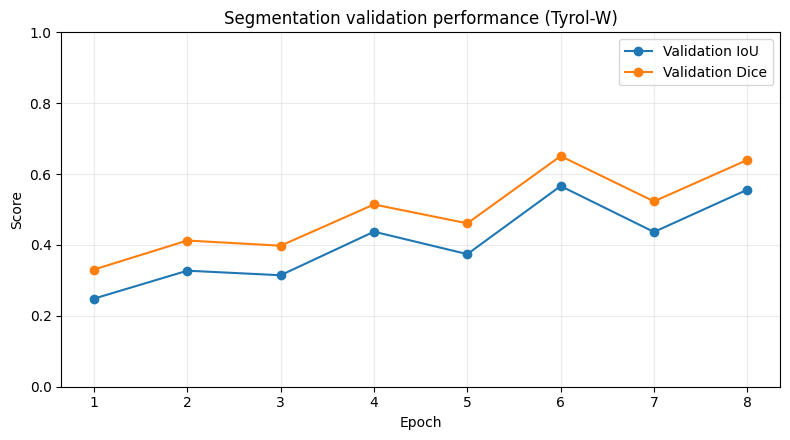

In [26]:
# Final evaluation is performed only once after model selection on Tyrol-W.
test_loss, test_patch_metrics = evaluate(test_loader)
part2_metrics = test_patch_metrics.mean().to_frame('mean').join(test_patch_metrics.std().to_frame('std'))
part2_metrics.to_csv(OUT/'part2_test_metrics.csv')
display(part2_metrics.round(4))

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(history_df.epoch,history_df.IoU,marker='o',label='Validation IoU')
ax.plot(history_df.epoch,history_df.Dice,marker='o',label='Validation Dice')
ax.set(title='Segmentation validation performance (Tyrol-W)',xlabel='Epoch',ylabel='Score',ylim=(0,1))
ax.grid(alpha=.25);ax.legend();fig.tight_layout();fig.savefig(OUT/'part2_training_curve.png',dpi=180);plt.show()

Total test patches: 576
Patches containing buildings: 543

Performance on non-empty building patches:


,mean,std
IoU,0.5920,0.1581
Dice,0.7278,0.1630
Precision,0.6418,0.1594
Recall,0.8790,0.1610



Selected non-trivial qualitative cases:
Lowest-IoU: index=126, IoU=0.025, Dice=0.050, GT building coverage=1.8%
Median: index=322, IoU=0.636, Dice=0.777, GT building coverage=42.7%
Highest-IoU: index=464, IoU=0.893, Dice=0.943, GT building coverage=42.4%


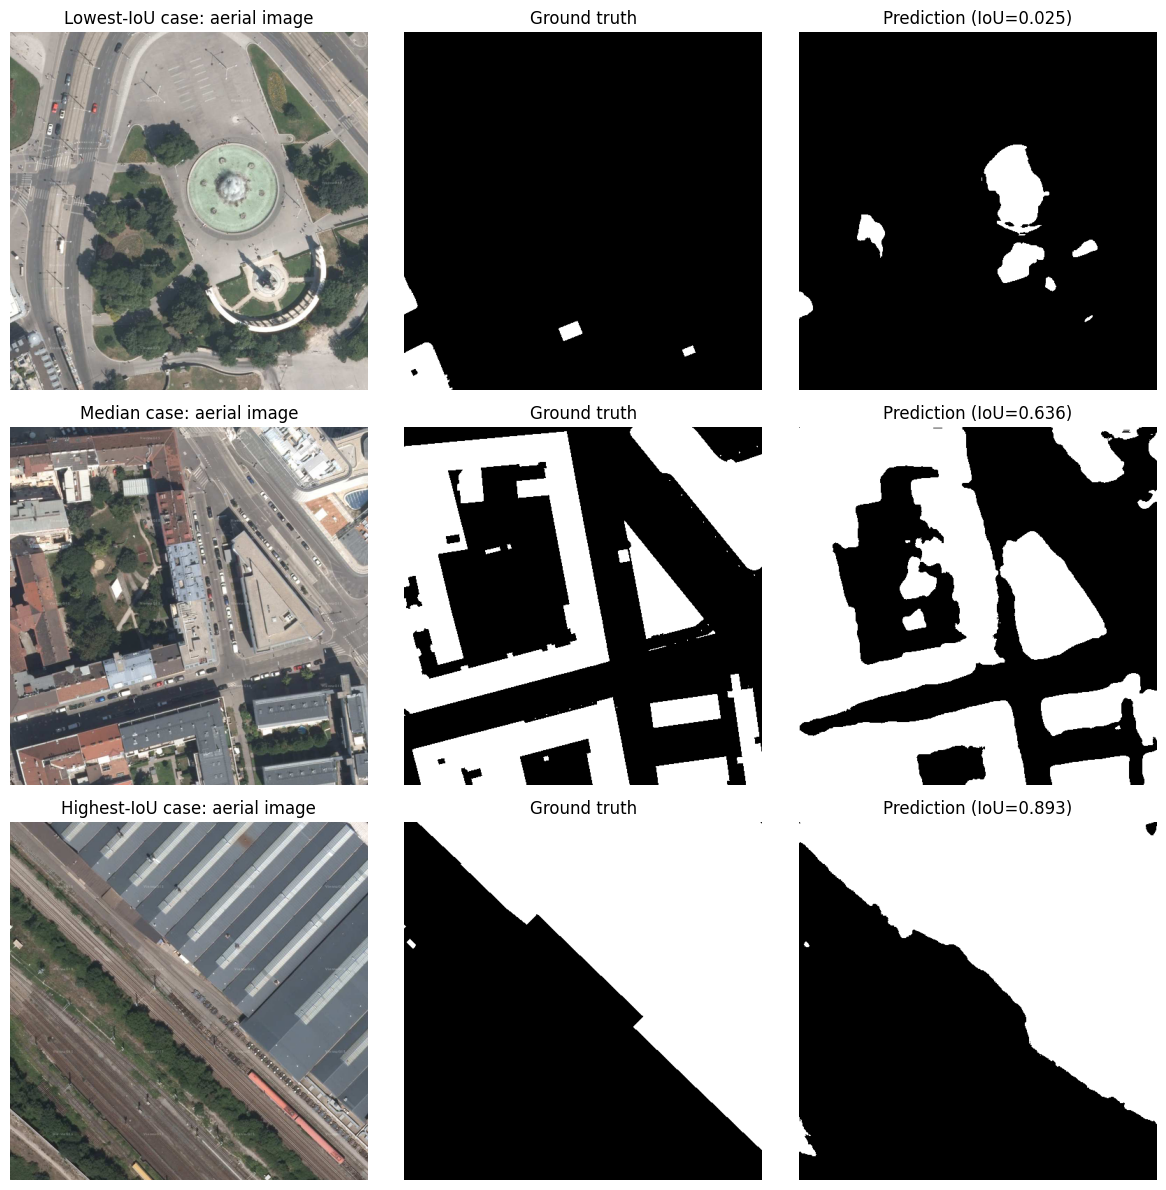


Saved: /content/unlv_assessment_outputs/part2_qualitative_nontrivial_cases.png


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

@torch.no_grad()
def analyze_positive_building_patches(loader):
    model.eval()
    rows = []
    global_idx = 0
    eps = 1e-7

    for xb, yb, meta in loader:
        logits = model(xb.to(DEVICE))
        pred = (torch.sigmoid(logits) >= 0.5).float().cpu()
        gt = (yb >= 0.5).float().cpu()

        inter = (pred * gt).sum(dim=(1,2,3))
        union = ((pred + gt) > 0).float().sum(dim=(1,2,3))

        pred_sum = pred.sum(dim=(1,2,3))
        gt_sum = gt.sum(dim=(1,2,3))

        iou = (inter + eps) / (union + eps)
        dice = (2 * inter + eps) / (pred_sum + gt_sum + eps)
        precision = (inter + eps) / (pred_sum + eps)
        recall = (inter + eps) / (gt_sum + eps)

        patch_pixels = gt.shape[-1] * gt.shape[-2]
        gt_fraction = gt_sum / patch_pixels

        for j in range(len(xb)):
            rows.append({
                "global_idx": global_idx + j,
                "IoU": float(iou[j]),
                "Dice": float(dice[j]),
                "Precision": float(precision[j]),
                "Recall": float(recall[j]),
                "gt_fraction": float(gt_fraction[j]),
                "gt_pixels": float(gt_sum[j])
            })

        global_idx += len(xb)

    return pd.DataFrame(rows)


positive_df = analyze_positive_building_patches(test_loader)

# -------------------------------------------------------
# Additional diagnostic:
# performance only where the GT actually contains buildings
# -------------------------------------------------------
nonempty_df = positive_df[positive_df["gt_pixels"] > 0].copy()

print("Total test patches:", len(positive_df))
print("Patches containing buildings:", len(nonempty_df))
print()

print("Performance on non-empty building patches:")
display(
    nonempty_df[
        ["IoU", "Dice", "Precision", "Recall"]
    ].agg(["mean", "std"]).T.round(4)
)

# -------------------------------------------------------
# Qualitative examples:
# require at least 1% building pixels so that the
# 'best case' is a meaningful building-segmentation example
# -------------------------------------------------------
qual_df = positive_df[
    positive_df["gt_fraction"] >= 0.01
].sort_values("IoU").reset_index(drop=True)

if len(qual_df) < 3:
    raise RuntimeError(
        "Not enough building-containing patches for qualitative analysis."
    )

selected = {
    "Lowest-IoU": qual_df.iloc[0],
    "Median": qual_df.iloc[len(qual_df)//2],
    "Highest-IoU": qual_df.iloc[-1]
}

print("\nSelected non-trivial qualitative cases:")
for name, row in selected.items():
    print(
        f"{name}: index={int(row.global_idx)}, "
        f"IoU={row.IoU:.3f}, "
        f"Dice={row.Dice:.3f}, "
        f"GT building coverage={100*row.gt_fraction:.1f}%"
    )


# -------------------------------------------------------
# Retrieve the selected images
# -------------------------------------------------------
wanted = {
    int(row.global_idx): name
    for name, row in selected.items()
}

samples = {}
global_idx = 0

model.eval()

with torch.no_grad():
    for xb, yb, meta in test_loader:

        logits = model(xb.to(DEVICE))
        pred = (torch.sigmoid(logits) >= 0.5).float().cpu()

        for j in range(len(xb)):
            idx = global_idx + j

            if idx in wanted:
                name = wanted[idx]

                img = xb[j].cpu().permute(1,2,0).numpy()

                mean = IMAGENET_MEAN.view(3).cpu().numpy().reshape(1,1,3)
                std = IMAGENET_STD.view(3).cpu().numpy().reshape(1,1,3)

                img = np.clip(img * std + mean, 0, 1)

                gt = yb[j,0].cpu().numpy()
                pr = pred[j,0].numpy()

                samples[name] = (img, gt, pr)

        global_idx += len(xb)

        if len(samples) == 3:
            break


# -------------------------------------------------------
# Plot
# -------------------------------------------------------
order = ["Lowest-IoU", "Median", "Highest-IoU"]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for r, name in enumerate(order):
    img, gt, pr = samples[name]
    row = selected[name]

    axes[r,0].imshow(img)
    axes[r,0].set_title(f"{name} case: aerial image")

    axes[r,1].imshow(gt, cmap="gray")
    axes[r,1].set_title("Ground truth")

    axes[r,2].imshow(pr, cmap="gray")
    axes[r,2].set_title(
        f"Prediction (IoU={row.IoU:.3f})"
    )

    for c in range(3):
        axes[r,c].axis("off")

plt.tight_layout()

out_path = OUT / "part2_qualitative_nontrivial_cases.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved:", out_path)

## 7. Error analysis
The quantitative metrics should be read together with the three qualitative cases above. In the written report I distinguish:
- **false positives** (e.g., bright parking lots, concrete surfaces, containers, or road structures that resemble roofs),
- **false negatives** (small or tree-occluded buildings), and
- **boundary errors** (correct object detection but imprecise footprint edges).

This matters because overall pixel accuracy can remain high even when a minority building class is poorly delineated. IoU, Dice, precision/recall, and Boundary F1 are therefore reported instead.